In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use('dark_background')

### Consider the following salary data

In [2]:
df = pd.read_csv('salary.csv')
df.head()

,YearsExperience,Salary,age,company_change,type
0,1.1,39343,21,1,junior
1,1.3,46205,31,0,middle
2,1.5,37731,29,1,middle
3,2.0,43525,30,1,middle
4,2.2,39891,27,1,middle


# Gradient Descent:
<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>We follow the steps below: </h3>
    
- Take the derivative of the loss function for each parameter in it i.e take the gradient of the loss function.
- Pick random values for the parameters.
- Plug the parameter into the derivatives.
- Calculate the step sizes = slope*learning rate
- Updated parameter value = Old value - step size
- Repeat

</div>


### For the salary data let's try to predict the salary based on just the years of experience and without any bias term i.e.

$Salary = 0 + (slope)*YearsExp = \beta_1*YearsExp$

In [3]:
# Seperate X and y. 
X = df['YearsExperience']
y = df['Salary']

---

### For Linear regression:

$Loss function = (1/N)*\Sigma_i (y_{ai} - y_{pi})^2$<br>
$=> Loss function = 1/N * \Sigma(y_{ai} - (0+\beta_i * YrsExp_i))^2$<br>
$=> Loss function = 1/N * \Sigma(y_{ai} - \beta_i * YrsExp_i)^2$

---

## <u>Performing GD:</u>

#### Step 1: Take the derivative of the loss function wrt beta_i

$\frac{\partial LF}{\partial \beta_i} = -2/N * \Sigma(y_{ai} - \beta_i * YrsExp_i) * YrsExp_i$

In [4]:
N = len(X)

assert len(X)==len(y)

#### Step 2: Pick random value of the parameter $\beta_i$

In [5]:
beta_1 = y.mean()/X.mean()
beta_1

14304.203262233375

#### Step 3: Plug $\beta_i$ into the derivative

In [6]:
residuals = y - beta_1 * X
sum_res = sum(residuals*X)
diff_lf_beta_1 = -2/N * sum_res
diff_lf_beta_1

75582.0416562108

#### Step 4: Calculate step size = derivative * learning rate

In [7]:
learning_rate = 0.01

In [8]:
step_size = diff_lf_beta_1 * learning_rate
step_size

755.820416562108

#### Step 5: Update parameter as : new beta_i = old beta_i - step size

In [9]:
print(f"Parameter before: {beta_1}")
beta_1 = beta_1 - step_size
print(f"Parameter after: {beta_1}")

Parameter before: 14304.203262233375
Parameter after: 13548.382845671267


#### We repeat the steps above. But how many times? So, we ask a question.

#### When does GD stop?
    
        It stops when the step_size is nearly equal to 0.
        In practice, however, we continue until step_size <= 0.0001 or until number of iterations = 1000

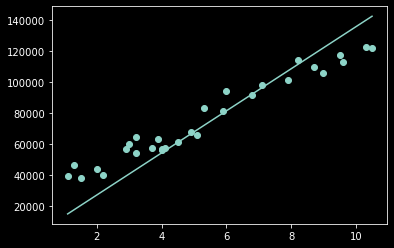

In [10]:
fig, ax = plt.subplots()
ax.scatter(X, y)
preds = beta_1*X.to_numpy().reshape(-1, 1).flatten()
ax.plot(X, preds)

In [11]:
N = len(X)

beta_1 = y.mean()/X.mean()

iterations = 1000
for i in range(iterations+1):
    residuals = y - beta_1 * X
    sum_res = sum(residuals*X)
    diff_lf_beta_1 = -2/N * sum_res

    learning_rate = 0.001
    step_size = diff_lf_beta_1 * learning_rate
    beta_1 = beta_1 - step_size
    
    if i%50==0:
        print(f"Parameter value after {i} iterations: {beta_1} and step size: {step_size}")

Parameter value after 0 iterations: 14228.621220577164 and step size: 75.5820416562108
Parameter value after 50 iterations: 13278.114337820209 and step size: 1.7990259718190433
Parameter value after 100 iterations: 13255.490093608198 and step size: 0.042820944980570735
Parameter value after 150 iterations: 13254.951584697372 and step size: 0.0010192367190087679
Parameter value after 200 iterations: 13254.938766949988 and step size: 2.4260171947147077e-05
Parameter value after 250 iterations: 13254.938461858199 and step size: 5.774477069887022e-07
Parameter value after 300 iterations: 13254.938454596315 and step size: 1.3744600194816787e-08
Parameter value after 350 iterations: 13254.938454423464 and step size: 3.270766076942285e-10
Parameter value after 400 iterations: 13254.938454419353 and step size: 7.89295881986618e-12
Parameter value after 450 iterations: 13254.938454419262 and step size: 8.16847508152326e-13
Parameter value after 500 iterations: 13254.938454419262 and step size: 

### I don't trust anything above. Show me the library solution first.

In [12]:
from sklearn.linear_model import LinearRegression as LR

model = LR(fit_intercept=False)
X = X.to_numpy().reshape(-1, 1)
model.fit(X, y)

LinearRegression(fit_intercept=False)

In [13]:
beta_1_model = model.coef_
beta_1_model

array([13254.93845442])

In [14]:
round(beta_1, 3) == round(beta_1_model[0], 3)

True

#### THEY MATCH!!

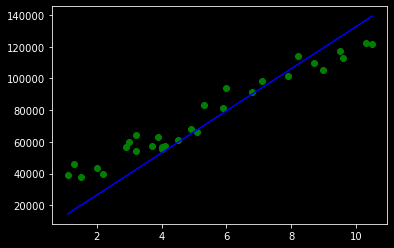

In [16]:
plt.scatter(X, y,color='g')
plt.plot(X, model.predict(X.reshape(-1, 1)), color='b')

plt.show()

---